# Customer Purchasing Behavior Analysis
Exploratory data analysis to explore customer purchasing behavior,
check the impact of promotions and store openings on purchasing behavior.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging


### Configure the Logger

In [42]:
# Configure logging
logging.basicConfig(level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    handlers=[logging.FileHandler("analysis.log"), logging.StreamHandler()])

###  Log Your Steps

In [43]:
import pandas as pd
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    handlers=[logging.FileHandler("analysis.log"), logging.StreamHandler()])

# Log the start of the analysis
logging.info("Starting the customer purchasing behavior analysis.")

# Load the datasets
try:
    train_data = pd.read_csv('../data/train.csv', low_memory=False)
    logging.info("Loaded training data successfully.")
except FileNotFoundError:
    logging.error("Training data file not found.")
    
try:
    test_data = pd.read_csv('../data/test.csv', low_memory=False)
    logging.info("Loaded test data successfully.")
except FileNotFoundError:
    logging.error("Test data file not found.")

try:
    store_data = pd.read_csv('../data/store.csv', low_memory=False)
    logging.info("Loaded store data successfully.")
except FileNotFoundError:
    logging.error("Store data file not found.")

# Merge the training data with the store data
merged_data = pd.merge(train_data, store_data, on='Store', how='left')
logging.info("Merged training data with store data.")

# Display the first few rows of the merged data
logging.info("First few rows of merged data:\n%s", merged_data.head())

# Continue with your analysis...

2025-01-03 17:13:00,327 - INFO - Starting the customer purchasing behavior analysis.
2025-01-03 17:13:01,265 - INFO - Loaded training data successfully.
2025-01-03 17:13:01,308 - INFO - Loaded test data successfully.
2025-01-03 17:13:01,315 - INFO - Loaded store data successfully.
2025-01-03 17:13:01,643 - INFO - Merged training data with store data.
2025-01-03 17:13:01,644 - INFO - First few rows of merged data:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a         

### Load Data

In [20]:
import pandas as pd

# Load the datasets with dtype option to handle mixed types
train_data = pd.read_csv('../data/train.csv', low_memory=False)  # Use low_memory=False to suppress the warning
test_data = pd.read_csv('../data/test.csv', low_memory=False)    # Use low_memory=False to suppress the warning
store_data = pd.read_csv('../data/store.csv', low_memory=False)  # Use low_memory=False to suppress the warning

# Display the first few rows of each dataset
print("Train Data:")
print(train_data.head())
print("\nTest Data:")
print(test_data.head())
print("\nStore Data:")
print(store_data.head())

# Merge the training data with the store data
merged_data = pd.merge(train_data, store_data, on='Store', how='left')

# Verify the merged DataFrame
print("\nColumns in Merged Data:", merged_data.columns.tolist())
print("First Few Rows of Merged Data:\n", merged_data.head())

Train Data:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  

Test Data:
   Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday
0   1      1          4  2015-09-17   1.0      1            0              0
1   2      3          4  2015-09-17   1.0      1            0              0
2   3      7          4  2015-09-17   1.0      1            0              0
3   4      8          4  2015-09-17   1.0      1            0              0
4 

## data cleaning process

In [21]:
# Check for missing values
missing_train = train_data.isnull().sum()
missing_test = test_data.isnull().sum()

# Display missing values
print("Missing values in training data:\n", missing_train[missing_train > 0])
print("\nMissing values in test data:\n", missing_test[missing_test > 0])

# Check for duplicates
duplicates_train = train_data.duplicated().sum()
duplicates_test = test_data.duplicated().sum()

print(f"\nDuplicates in training data: {duplicates_train}")
print(f"Duplicates in test data: {duplicates_test}")

# Handle missing values (example: drop rows with missing target variable 'Sales')
train_data.dropna(subset=['Sales'], inplace=True)

# Handle outliers (example: using IQR method)
Q1 = train_data['Sales'].quantile(0.25)
Q3 = train_data['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
train_data = train_data[(train_data['Sales'] >= lower_bound) & (train_data['Sales'] <= upper_bound)]

# Check data types
print("\nData types in training data:\n", train_data.dtypes)
print("\nData types in test data:\n", test_data.dtypes)

# Convert data types if necessary (example: convert 'Date' to datetime)
train_data['Date'] = pd.to_datetime(train_data['Date'])
test_data['Date'] = pd.to_datetime(test_data['Date'])

Missing values in training data:
 Series([], dtype: int64)

Missing values in test data:
 Open    11
dtype: int64

Duplicates in training data: 0
Duplicates in test data: 0

Data types in training data:
 Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

Data types in test data:
 Id                 int64
Store              int64
DayOfWeek          int64
Date              object
Open             float64
Promo              int64
StateHoliday      object
SchoolHoliday      int64
dtype: object


### Handle missing values in test data

In [22]:
# Handle missing values in test data
test_data['Open'].fillna(1, inplace=True)  # Assuming missing means the store is open

# Convert 'Open' column to int
test_data['Open'] = test_data['Open'].astype(int)

# Verify changes
print("\nMissing values in test data after handling:\n", test_data.isnull().sum())
print("\nData types in test data after conversion:\n", test_data.dtypes)


Missing values in test data after handling:
 Id               0
Store            0
DayOfWeek        0
Date             0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Data types in test data after conversion:
 Id                        int64
Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object


C:\Users\HP 830 G6\AppData\Local\Temp\ipykernel_11880\1338748617.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Open'].fillna(1, inplace=True)  # Assuming missing means the store is open


### Exploartory Data Analysis

#### 1. Distribution of Promotions in Training and Test Sets

2025-01-03 17:16:54,500 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-03 17:16:55,292 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-03 17:16:55,669 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-03 17:16:55,706 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


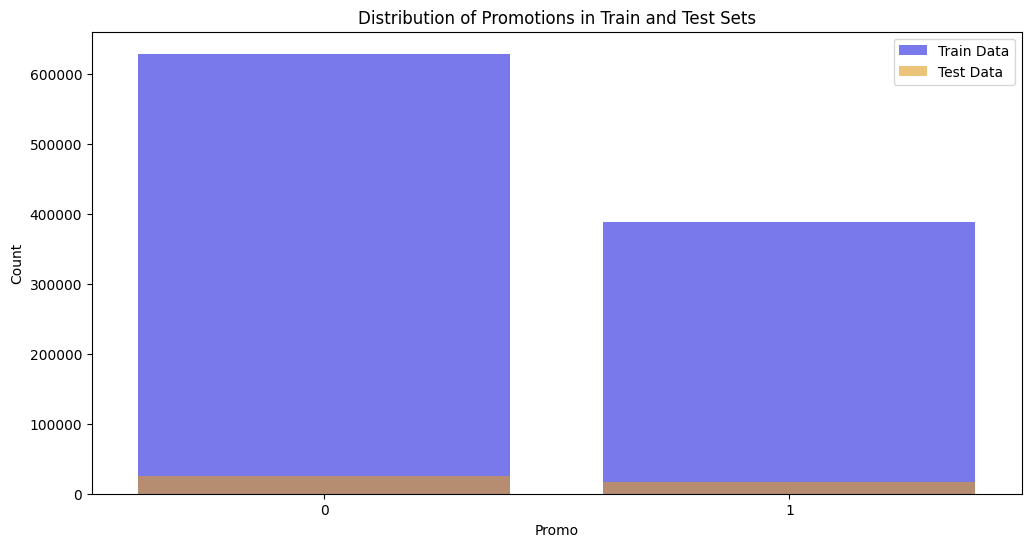

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of promotions in training and test sets
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Promo', color='blue', label='Train Data', alpha=0.6)
sns.countplot(data=test_data, x='Promo', color='orange', label='Test Data', alpha=0.6)
plt.title('Distribution of Promotions in Train and Test Sets')
plt.xlabel('Promo')
plt.ylabel('Count')
plt.legend()
plt.show()

#### 2. Sales Behavior Before, During, and After Holidays

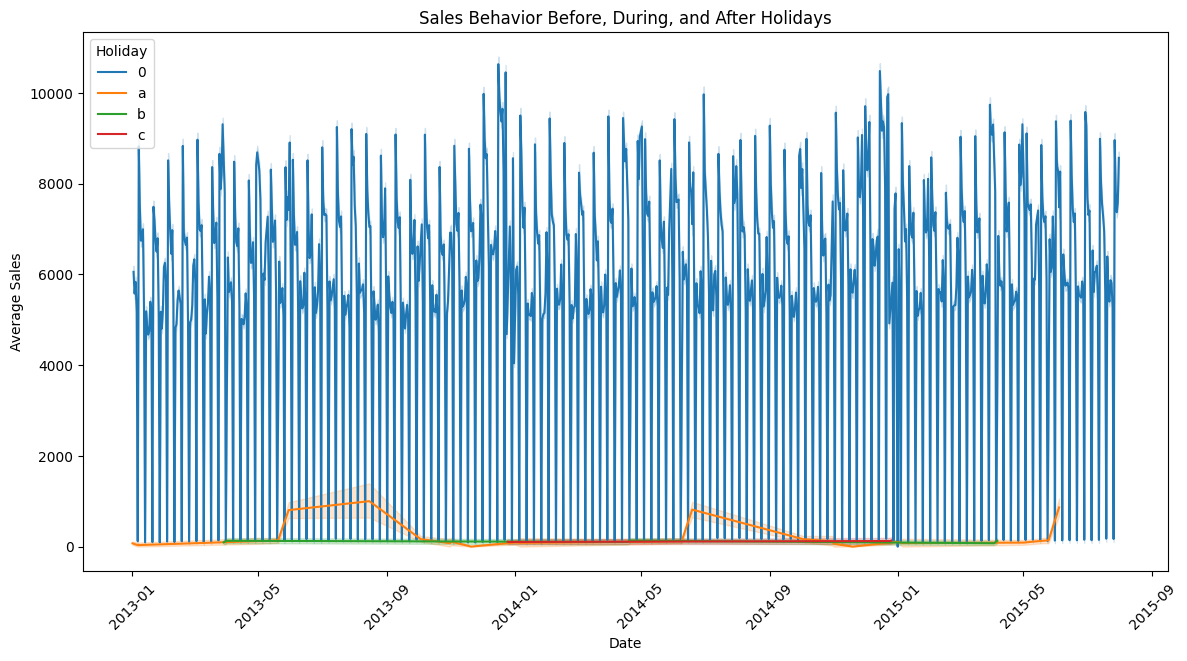

In [27]:
# Assuming 'Date' is in datetime format and 'Sales' is the sales column
train_data['Date'] = pd.to_datetime(train_data['Date'])
train_data['Holiday'] = train_data['StateHoliday'].replace({0: 'No Holiday', 1: 'Holiday'})

plt.figure(figsize=(14, 7))
sns.lineplot(data=train_data, x='Date', y='Sales', hue='Holiday', estimator='mean')
plt.title('Sales Behavior Before, During, and After Holidays')
plt.xlabel('Date')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

#### 3. Seasonal Purchase Behaviors

2025-01-03 16:46:35,630 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-03 16:46:36,271 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


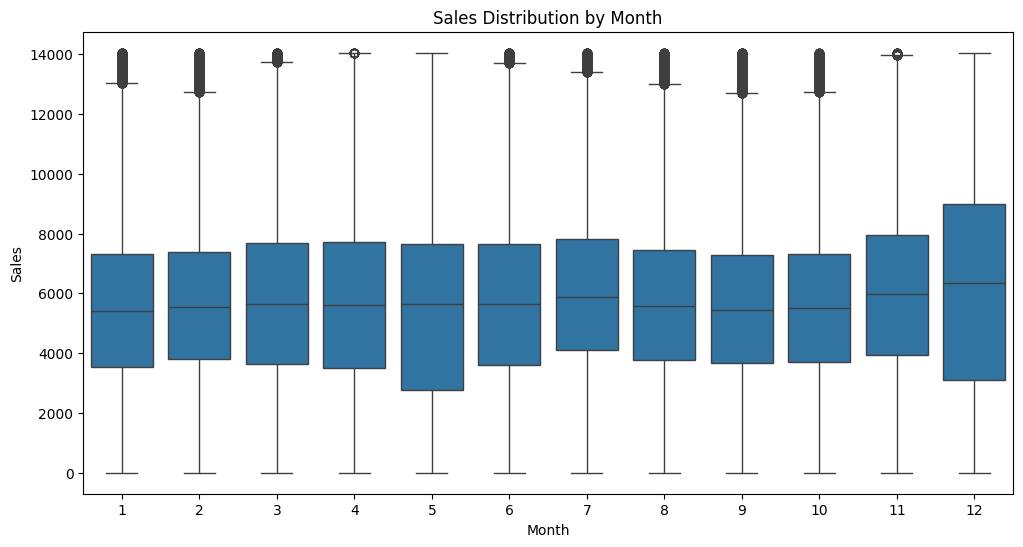

In [28]:
train_data['Month'] = train_data['Date'].dt.month
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Month', y='Sales')
plt.title('Sales Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

#### 4. Correlation Between Sales and Number of Customers

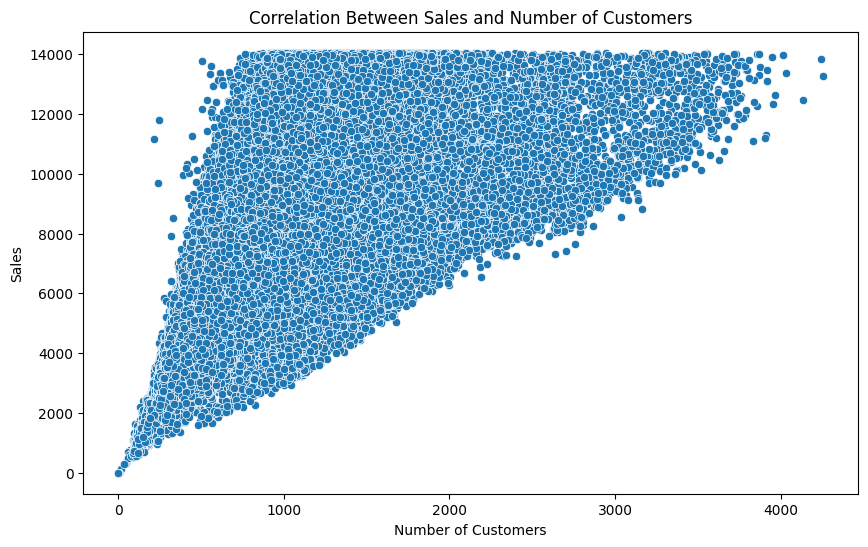

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_data, x='Customers', y='Sales')
plt.title('Correlation Between Sales and Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Sales')
plt.show()

#### 5. Effect of Promotions on Sales

2025-01-03 16:48:35,337 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-03 16:48:36,002 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


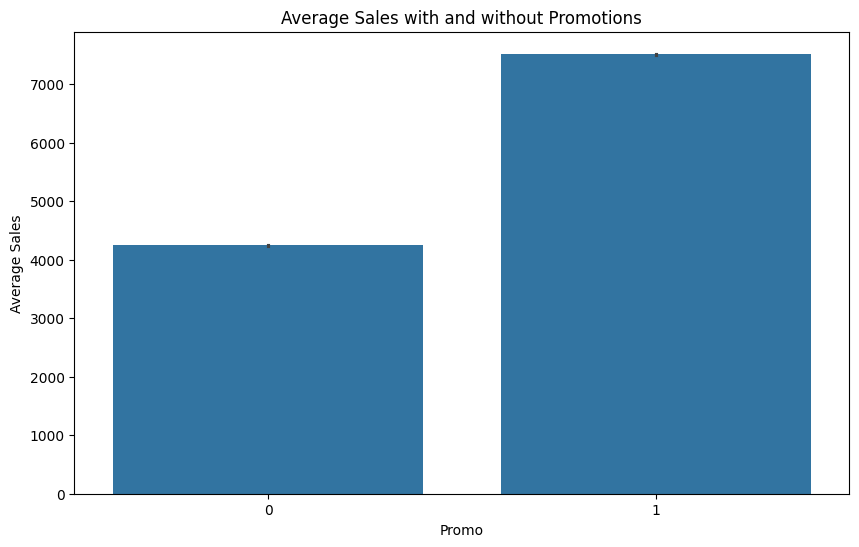

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(data=train_data, x='Promo', y='Sales', estimator='mean')
plt.title('Average Sales with and without Promotions')
plt.xlabel('Promo')
plt.ylabel('Average Sales')
plt.show()

#### 6. Trends of Customer Behavior During Store Opening and Closing Times

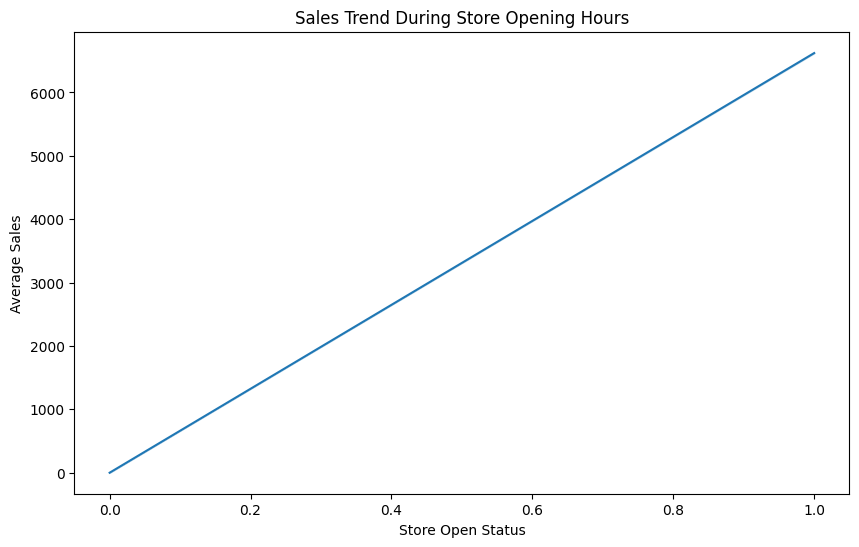

In [31]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_data, x='Open', y='Sales', estimator='mean')
plt.title('Sales Trend During Store Opening Hours')
plt.xlabel('Store Open Status')
plt.ylabel('Average Sales')
plt.show()

#### 7. Stores Open on All Weekdays

Columns in merged data: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


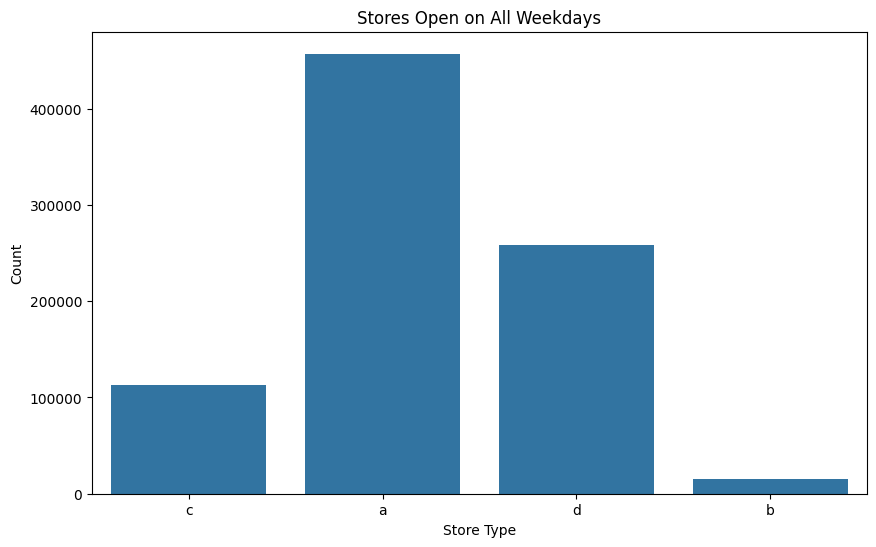

In [35]:


# Load the datasets
train_data = pd.read_csv('../data/train.csv', low_memory=False)
test_data = pd.read_csv('../data/test.csv', low_memory=False)
store_data = pd.read_csv('../data/store.csv', low_memory=False)

# Merge the training data with the store data
merged_data = pd.merge(train_data, store_data, on='Store', how='left')

# Check the columns in the merged data
print("Columns in merged data:", merged_data.columns.tolist())

# Filter for stores that are open on all weekdays
stores_open_weekdays = merged_data[merged_data['Open'] == 1]

# Check if StoreType exists in the merged data
if 'StoreType' in stores_open_weekdays.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=stores_open_weekdays, x='StoreType')
    plt.title('Stores Open on All Weekdays')
    plt.xlabel('Store Type')
    plt.ylabel('Count')
    plt.show()
else:
    print("StoreType column does not exist in the filtered data.")

#### 8. Assortment Type Effect on Sales

Columns in merged data: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


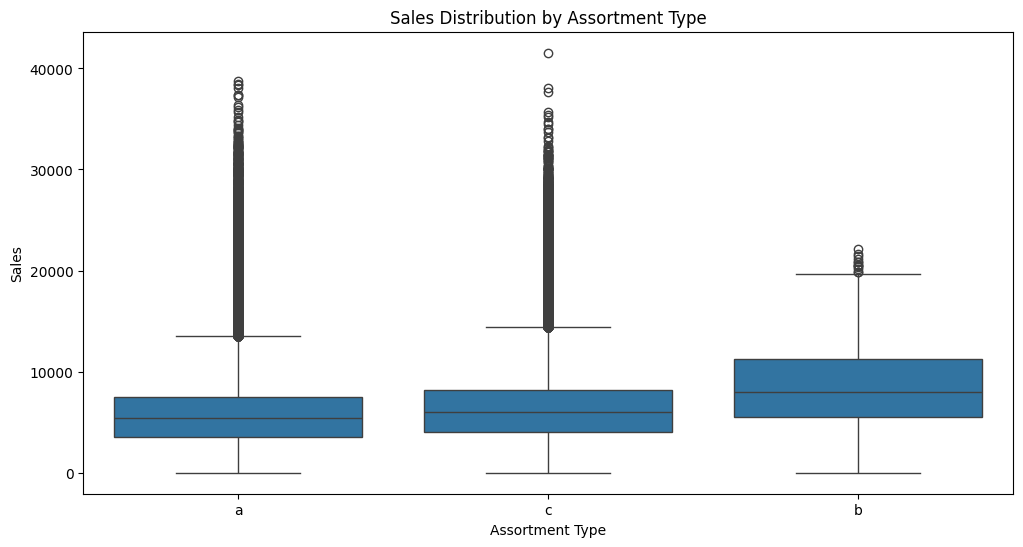

In [37]:




# Merge the training data with the store data
merged_data = pd.merge(train_data, store_data, on='Store', how='left')

# Check the columns in the merged data
print("Columns in merged data:", merged_data.columns.tolist())

# Create a boxplot for Sales by Assortment Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_data, x='Assortment', y='Sales')
plt.title('Sales Distribution by Assortment Type')
plt.xlabel('Assortment Type')
plt.ylabel('Sales')
plt.show()

#### 9. Distance to Competitors Effect on Sales

Columns in merged data: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


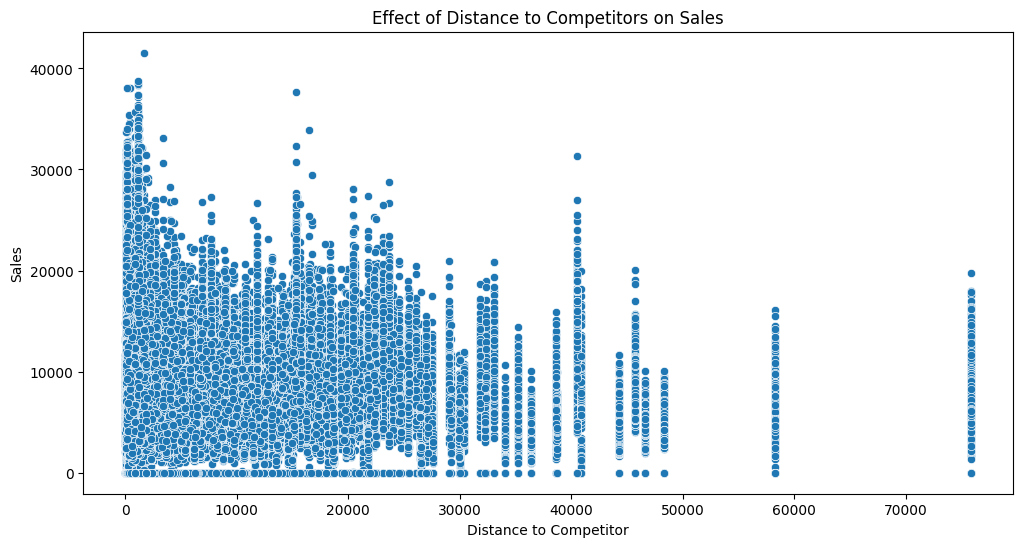

In [40]:


# Merge the training data with the store data
merged_data = pd.merge(train_data, store_data, on='Store', how='left')

# Check the columns in the merged data
print("Columns in merged data:", merged_data.columns.tolist())

# Create a scatter plot for CompetitionDistance vs Sales
plt.figure(figsize=(12, 6))
sns.scatterplot(data=merged_data, x='CompetitionDistance', y='Sales')
plt.title('Effect of Distance to Competitors on Sales')
plt.xlabel('Distance to Competitor')
plt.ylabel('Sales')
plt.show()

#### 10. Opening/Reopening of New Competitors

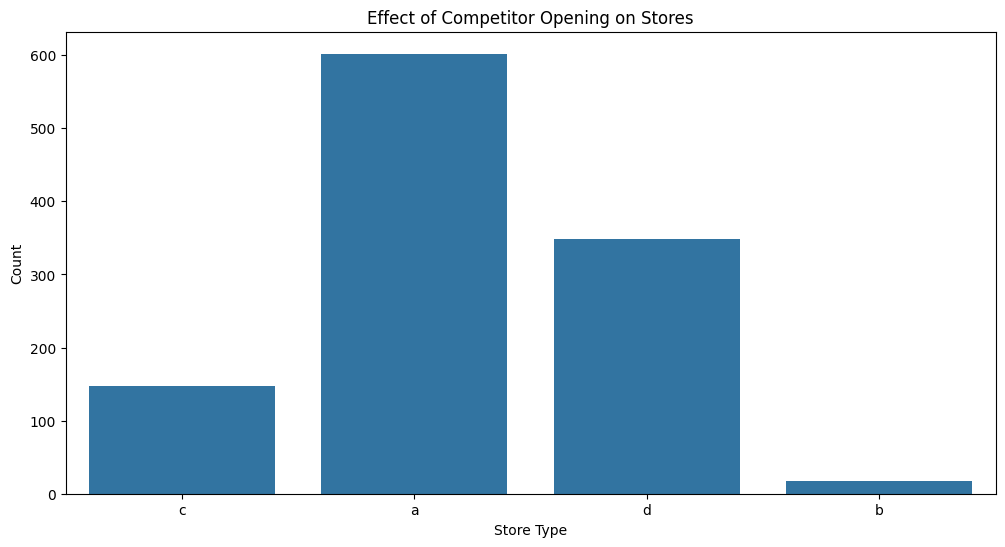

In [41]:
# Assuming you have a column 'CompetitorDistance' in your dataset
competitor_changes = store_data[store_data['CompetitionDistance'].isnull() | store_data['CompetitionDistance'].notnull()]
plt.figure(figsize=(12, 6))
sns.countplot(data=competitor_changes, x='StoreType')
plt.title('Effect of Competitor Opening on Stores')
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.show()